# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name:



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [130]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 1. Business Understanding
Goal: ?

# 2. Data Understanding

## 2.1 Load dataset

In [131]:
## Read *.csv file into pandas DataFrame
# Load the dataset
df = pd.read_csv('ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv')

# Display the first few rows to confirm loading
df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


## 2.2 Summary Statistics

In [132]:
## Understand the type of variable for each column
# Display data types and structure info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234316 entries, 0 to 234315
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                234316 non-null  object 
 1   town                 234316 non-null  object 
 2   flat_type            234316 non-null  object 
 3   block                234316 non-null  object 
 4   street_name          234316 non-null  object 
 5   storey_range         234316 non-null  object 
 6   floor_area_sqm       234316 non-null  float64
 7   flat_model           234316 non-null  object 
 8   lease_commence_date  234316 non-null  int64  
 9   remaining_lease      234316 non-null  object 
 10  resale_price         234316 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 19.7+ MB


In [133]:
## Check for missing data
# Display total count of missing data per column
df.isnull().sum()

month                  0
town                   0
flat_type              0
block                  0
street_name            0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
remaining_lease        0
resale_price           0
dtype: int64

**Interpretation**:The dataset has no missing values accross the 11 columns, Hence no imputation or row removal is needed before proceeding.

In [134]:
## Describe data distribution
# Summary statistics for numeric and categorical columns
print("Numeric Summary:")
print(df.describe())

print("\nCategorical Summary:")
print(df.describe(include=['O']))

Numeric Summary:
       floor_area_sqm  lease_commence_date  resale_price
count   234316.000000        234316.000000  2.343160e+05
mean        96.686849          1996.556155  5.315292e+05
std         24.017271            14.363498  1.905010e+05
min         31.000000          1966.000000  1.400000e+05
25%         81.000000          1985.000000  3.900000e+05
50%         93.000000          1997.000000  5.000000e+05
75%        112.000000          2012.000000  6.388880e+05
max        366.700000          2022.000000  1.728000e+06

Categorical Summary:
          month      town flat_type   block     street_name storey_range  \
count    234316    234316    234316  234316          234316       234316   
unique      114        26         7    2765             578           17   
top     2024-07  SENGKANG    4 ROOM       2  YISHUN RING RD     04 TO 06   
freq       3036     19009     99477     706            3316        53732   

       flat_model     remaining_lease  
count      234316          

**Interpretation**: The summary statistics show that for resale_price the mean (~$531K) is higher than median (~$500K), which indicates a right-skewed distribution,and a small number of more expensive flat prices that increase the mean.

floor_area_sqm ranges from 31 to 366.7 sqm, although the max is unusually large it is not an error but real flat types like  rare Terrace/Maisonette.

lease_commence_date spans 1966–2022 which shows a variety of flat ages in the dataset.

The dataset contains 26 unique towns, With Sengkang having the most frequent number of transactions (19,009)
 4 ROOM in flat_type is the most frequently occurring flat type at 99,477/ 234,316 which is 42% of all rows.

The remaining_lease variable contains 700 unique text values (e.g., "94 years 10 months"). It should be converted into a numeric format like 94.83(years) before modelling, for the model to perform calculations and identify relationships.


## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

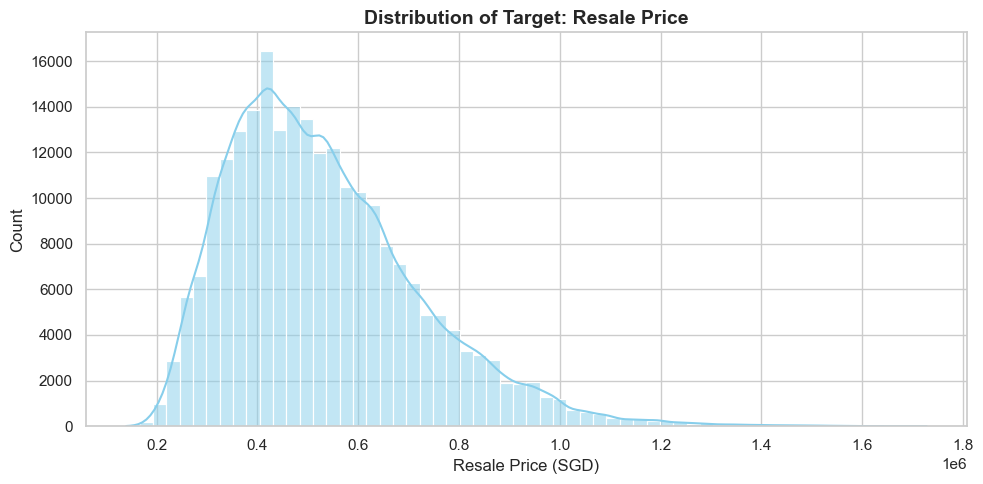

In [135]:
## Understanding distribution of target
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))
sns.histplot(df['resale_price'], bins=60, kde=True, color='skyblue')
plt.title('Distribution of Target: Resale Price', fontsize=14, fontweight='bold')
plt.xlabel('Resale Price (SGD)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


**Interpretation**: Based on this diagram showing the distribution of resale prices we can see that the distribution is right skewed, which matches the summary statistics earlier. The histogram shows, most transactions occur in the $300K–$600K range and there is a long right tail showing a smaller number of flats selling from 800K to $1.7M+.
The right-skewed distribution indicates that Linear Regression will struggle due to the small number of high-priced flats. Whereas Random Forest would be better for predicting rare and High-priced flats.


### 2.3.1.2 Understanding distribution of features

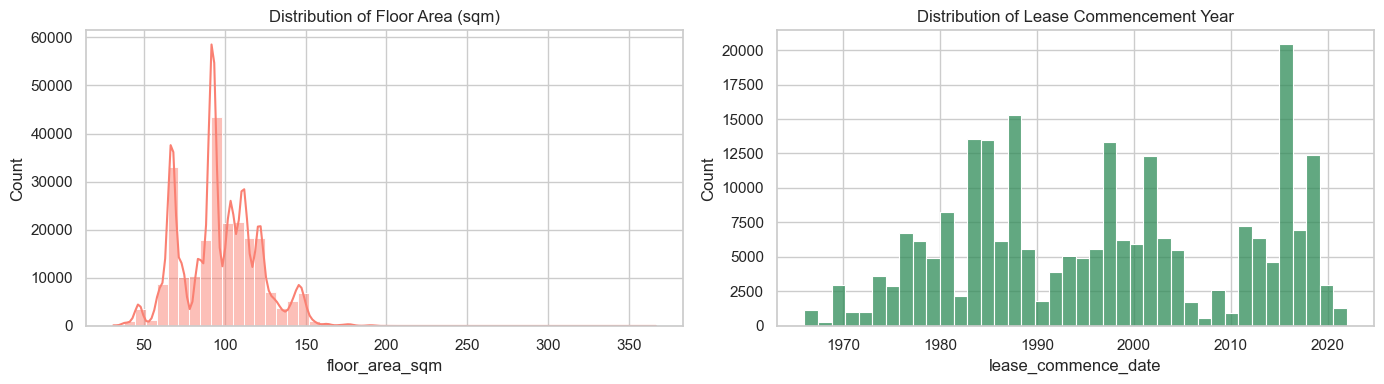

In [136]:
## Distribution of numeric features
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['floor_area_sqm'], bins=50, kde=True, color='salmon', ax=axes[0])
axes[0].set_title('Distribution of Floor Area (sqm)')
sns.histplot(df['lease_commence_date'], bins=40, kde=False, color='seagreen', ax=axes[1])
axes[1].set_title('Distribution of Lease Commencement Year')
plt.tight_layout()
plt.show()


**Interpretation**: From the diagram we can see that the distribution is multimodal with many bumps not one smooth curve. These Bumps roughly match common HDB unit sizes like, 60-70 sqm (3-room), ~90-95 sqm (4-room), ~110-120 sqm (5-room).Which makes sense as flat sizes are standardised by the type of flat.

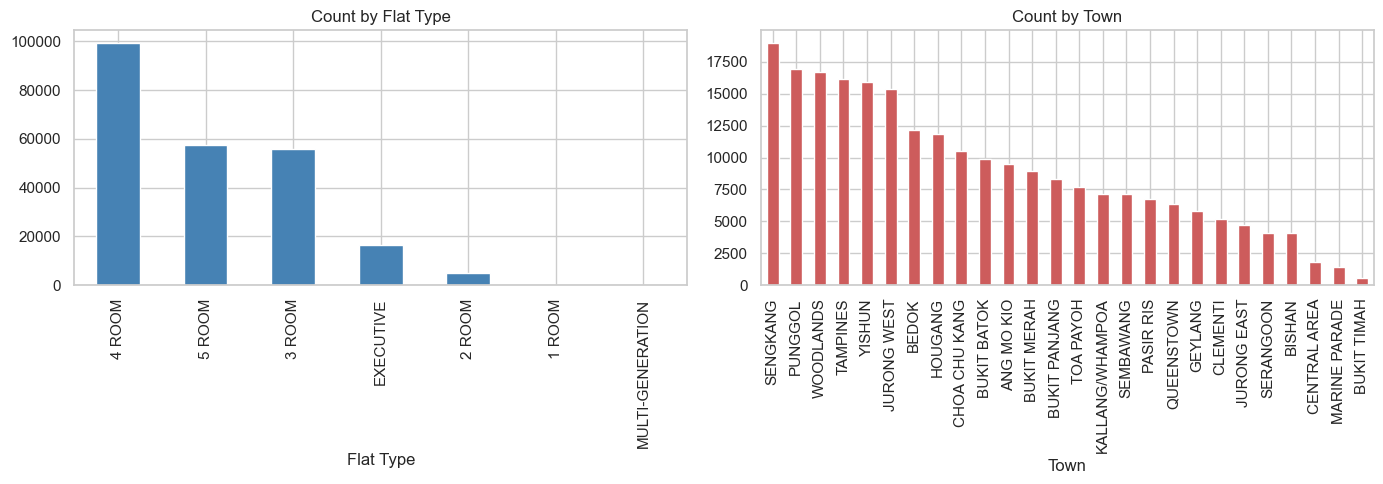

In [137]:
## Distribution of categorical features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['flat_type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Count by Flat Type')
axes[0].set_xlabel('Flat Type')

df['town'].value_counts().plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('Count by Town')
axes[1].set_xlabel('Town')
plt.tight_layout()
plt.show()


**Interpretation**: As seen from the findings in summary statistics we can see from the diagram that 
(4 Room) is the most common transaction type. However, (1 Room) and (MULTI-GENERATION) are rare with very few transactions, making them underrepresented in the dataset. As a result, predictions of underrepresented flat types may be less reliable due to the limited training examples.

### 2.3.2 Understanding relationship between variables

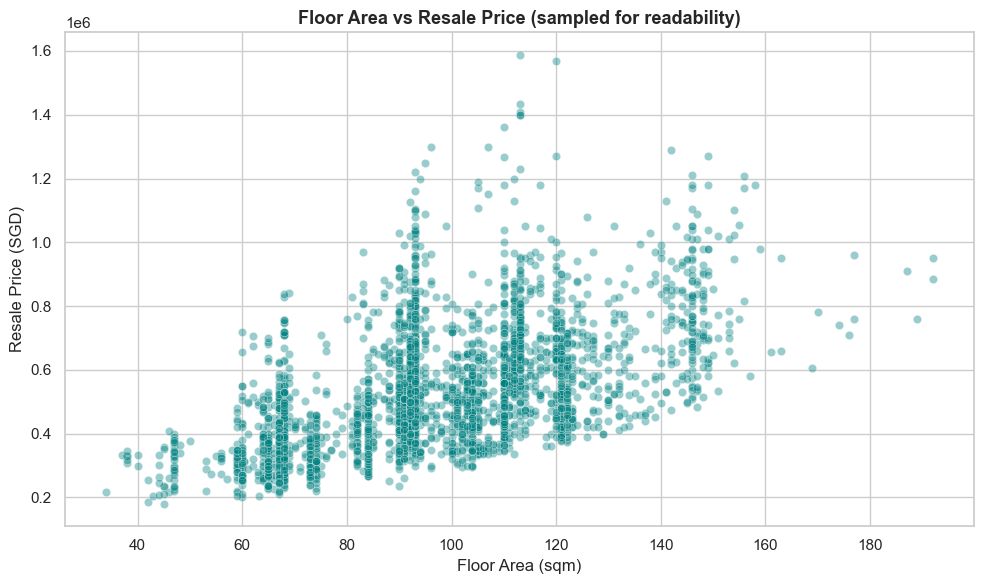

In [138]:
## Relationship: floor area vs resale price
plt.figure(figsize=(10, 6))
sample_df = df.sample(3000, random_state=RANDOM_STATE)
sns.scatterplot(data=sample_df, x='floor_area_sqm', y='resale_price', alpha=0.4, color='teal')
plt.title('Floor Area vs Resale Price (sampled for readability)', fontsize=13, fontweight='bold')
plt.xlabel('Floor Area (sqm)')
plt.ylabel('Resale Price (SGD)')
plt.tight_layout()
plt.show()

**Interpretation**: From this scatter plot we can see an upward trend as the floor area increases the price also increases, showing a positive correlation. We can also see that there is a spread at every size which shows the range in selling prices for the same sized flat. Therefore showing that floor are alone is not sufficient to accurately predict prices, and other features matter too.

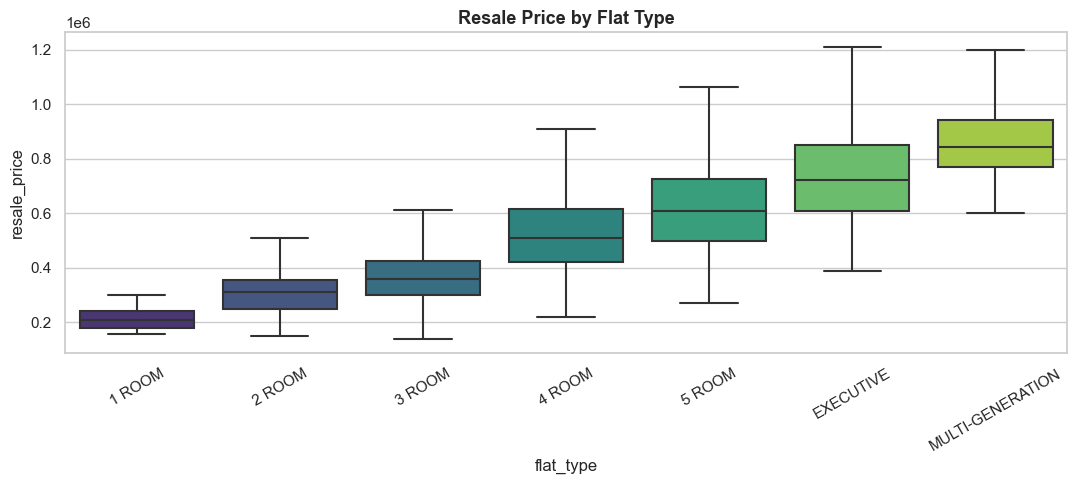

In [139]:
## Relationship: flat type vs resale price
plt.figure(figsize=(11, 5))
order = df.groupby('flat_type')['resale_price'].median().sort_values().index
sns.boxplot(data=df, x='flat_type', y='resale_price', order=order, showfliers=False, palette='viridis')
plt.title('Resale Price by Flat Type', fontsize=13, fontweight='bold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


**Interpretation**: From the boxplot we can see that Towns ordered by median price show a big gap between the most and least expensive towns. Furthermore, the width of boxes varies which indicates the price variation in different towns while some are more consistent. This shows that location is a major factor that contributes to price.

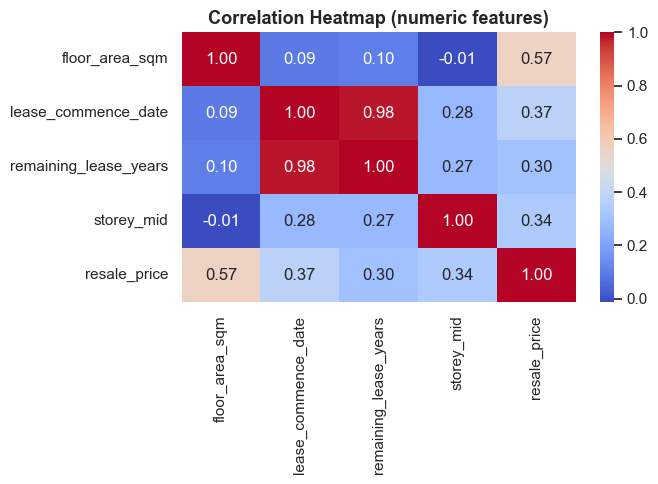

In [140]:
## Correlation heatmap of numeric features (after quick derivations for visualization only)
tmp = df.copy()
tmp['remaining_lease_years'] = tmp['remaining_lease'].str.extract(r'(\d+)\s*years?').astype(float)
tmp['storey_mid'] = tmp['storey_range'].str.split(' TO ').apply(lambda x: (int(x[0]) + int(x[1])) / 2)

corr_cols = ['floor_area_sqm', 'lease_commence_date', 'remaining_lease_years', 'storey_mid', 'resale_price']
plt.figure(figsize=(7, 5))
sns.heatmap(tmp[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (numeric features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation**:From the heatmap we can see that floor_area_sqm has the strongest correlation with resale_price (0.57) which shows that it is the top numeric predictor, matching the scatter plot. Lease_commence_date correlates at (0.37) showing newer flats tend to sell for more. Overall, no correlation is strong on its own, which shows categorical features are also important in explaining price and the model will need both feature types.

# 3. Data Preparation

## 3.1 Data Cleaning

In [141]:
## Clean data

data = df.copy()

# Parse remaining_lease text ("61 years 04 months") into a numeric year value
def parse_lease(text):
    years = 0
    months = 0
    parts = text.split()
    if 'years' in text or 'year' in text:
        years = int(parts[0])
    if 'months' in text or 'month' in text:
        nums = [int(p) for p in parts if p.isdigit()]
        months = nums[1] if len(nums) > 1 else 0
    return years + months / 12

data['remaining_lease_years'] = data['remaining_lease'].apply(parse_lease)

# Convert storey_range ("10 TO 12") into a numeric midpoint
data['storey_mid'] = data['storey_range'].str.split(' TO ').apply(lambda x: (int(x[0]) + int(x[1])) / 2)

# Derive transaction year and flat age at time of transaction
data['transaction_year'] = data['month'].str.slice(0, 4).astype(int)
data['flat_age'] = data['transaction_year'] - data['lease_commence_date']

# Drop columns that are identifiers or now-redundant text fields
data = data.drop(columns=['block', 'street_name', 'month', 'storey_range', 'remaining_lease'])

print(data.shape)
data.head()

(234316, 10)


,town,flat_type,floor_area_sqm,flat_model,lease_commence_date,resale_price,remaining_lease_years,storey_mid,transaction_year,flat_age
0,ANG MO KIO,2 ROOM,44.0,Improved,1979,232000.0,61.333333,11.0,2017,38
1,ANG MO KIO,3 ROOM,67.0,New Generation,1978,250000.0,60.583333,2.0,2017,39
2,ANG MO KIO,3 ROOM,67.0,New Generation,1980,262000.0,62.416667,2.0,2017,37
3,ANG MO KIO,3 ROOM,68.0,New Generation,1980,265000.0,62.083333,5.0,2017,37
4,ANG MO KIO,3 ROOM,67.0,New Generation,1980,265000.0,62.416667,2.0,2017,37


**Rationale** : In this data cleaning stage remaining_lease and storey_range that were both string were converted to numbers, to enable the model to use them.

block and street_name were dropped as there were too many unique values (2,765 and 578),which risks overfitting from one-hot-encoding. Town is sufficient in capturing the general location.

A new flat_age feature was created using the transaction year minus lease commencement. This feature will help the model learn the relationship between the flats age and resale price more easiely


## 3.2 Train-Test Split

In [142]:
## Split data into train set and test set


# Assumption: the full dataset has 234k+ rows. Training multiple models with
# RandomizedSearchCV on all of it is slow and unnecessary to demonstrate the process.
# We sample 15,000 rows (75x the minimum required sample size) to keep experimentation
# fast while remaining representative.
SAMPLE_SIZE = 15000
data_sample = data.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)

TARGET = 'resale_price'
X = data_sample.drop(columns=[TARGET])
y = data_sample[TARGET]

numeric_features = ['floor_area_sqm', 'lease_commence_date', 'remaining_lease_years',
                     'storey_mid', 'transaction_year', 'flat_age']
categorical_features = ['town', 'flat_type', 'flat_model']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (12000, 9)  Test shape: (3000, 9)


# 4. Modelling

### 4.2 Train Model

In [143]:
## Initialise and train model
## Build preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

## Initialise and train models
results = {}

# --- Baseline ---
baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)
results['Baseline (mean)'] = baseline

# --- Linear Regression ---
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
lr_pipeline.fit(X_train, y_train)
results['Linear Regression'] = lr_pipeline

# --- Random Forest ---
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=1))
])
rf_pipeline.fit(X_train, y_train)
results['Random Forest'] = rf_pipeline

print("Models trained:", list(results.keys()))


Models trained: ['Baseline (mean)', 'Linear Regression', 'Random Forest']


# 5. Model Evaluation

In [144]:
## Evaluate model

def evaluate(name, model, X_test, y_test):
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    return {'Model': name, 'MAE (SGD)': round(mae, 0), 'RMSE (SGD)': round(rmse, 0), 'R2': round(r2, 4)}

eval_rows = [evaluate(name, model, X_test, y_test) for name, model in results.items()]
eval_df = pd.DataFrame(eval_rows).set_index('Model')
eval_df


,MAE (SGD),RMSE (SGD),R2
Model,,,
Baseline (mean),151909.0,192507.0,-0.0001
Linear Regression,52945.0,69364.0,0.8702
Random Forest,37154.0,55186.0,0.9178


In [145]:
## New data

## Predict


## Iterative model development


In [146]:
## Further feature engineering / feature selection
## Feature engineering iteration: add town-level median price per sqm
# Computed on TRAIN data only, to avoid leakage into the test set
price_per_sqm_train = (y_train / X_train['floor_area_sqm'])
town_psm_median = price_per_sqm_train.groupby(X_train['town']).median()

def add_town_psm(X):
    X = X.copy()
    X['town_psm_median'] = X['town'].map(town_psm_median)
    X['town_psm_median'] = X['town_psm_median'].fillna(town_psm_median.median())
    return X

X_train_fe = add_town_psm(X_train)
X_test_fe = add_town_psm(X_test)

numeric_features_fe = numeric_features + ['town_psm_median']

preprocessor_fe = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features_fe),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

rf_fe_pipeline = Pipeline([
    ('preprocessor', preprocessor_fe),
    ('model', RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=1))
])
rf_fe_pipeline.fit(X_train_fe, y_train)

# Compare before vs after adding the engineered feature
comparison_df = pd.DataFrame([
    evaluate('Random Forest (original features)', results['Random Forest'], X_test, y_test),
    evaluate('Random Forest + town_psm_median', rf_fe_pipeline, X_test_fe, y_test)
]).set_index('Model')
comparison_df

,MAE (SGD),RMSE (SGD),R2
Model,,,
Random Forest (original features),37154.0,55186.0,0.9178
Random Forest + town_psm_median,34195.0,48691.0,0.9360


In [ ]:
## Hyperparameter tuning with RandomizedSearchCV (<=3 values per hyperparameter)
param_distributions = {
    'model__n_estimators': [50, 100, 150],
    'model__max_depth': [10, 20, None]
}

tuning_pipeline = Pipeline([
    ('preprocessor', preprocessor_fe),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1))
])

random_search = RandomizedSearchCV(
    tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=6,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=1
)
random_search.fit(X_train_fe, y_train)

cv_results = pd.DataFrame(random_search.cv_results_)[
    ['param_model__n_estimators', 'param_model__max_depth', 'mean_test_score', 'rank_test_score']
].sort_values('rank_test_score')
cv_results